### Imports

In [1]:
import glob
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchaudio
from IPython.display import Audio
from mpl_toolkits.axes_grid1 import make_axes_locatable
from tqdm import tqdm

from src.audio_dataset import AudioDataset
from src.cnn_model import CNNAudioClassifier
from src.config import AUDIO_CONFIG
from src.engine import benchmark_cnn
from src.preprocessing import get_waveform_transformer, get_spectrogram_transformer, get_cnn_pipeline
from src.utils import get_random_audio, get_split_dataloaders

warnings.filterwarnings("ignore", category=UserWarning)

### Constants

In [2]:
INPUT_DIR = 'data'
MODEL_PATH = 'models/best_cnn.pth'

# Hyperparameters
LR = 0.001
NUM_EPOCHS = 10

### Setting up device to use

In [3]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Visualising audio data

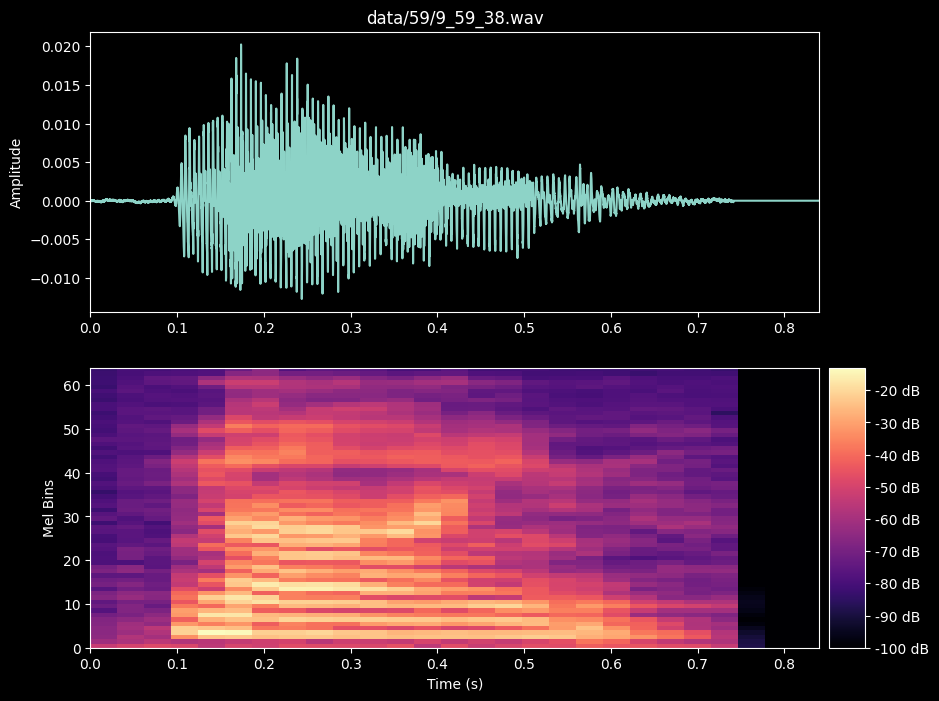

Original: 35588 samples (0.74s)
Preprocessed: 13440 samples (0.84s)


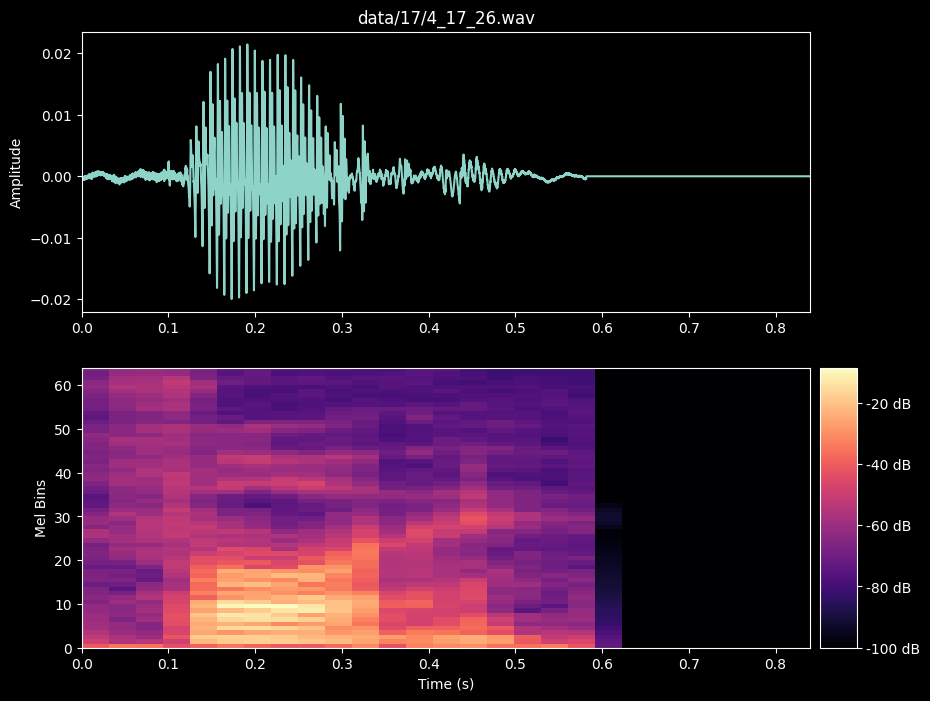

Original: 27924 samples (0.58s)
Preprocessed: 13440 samples (0.84s)


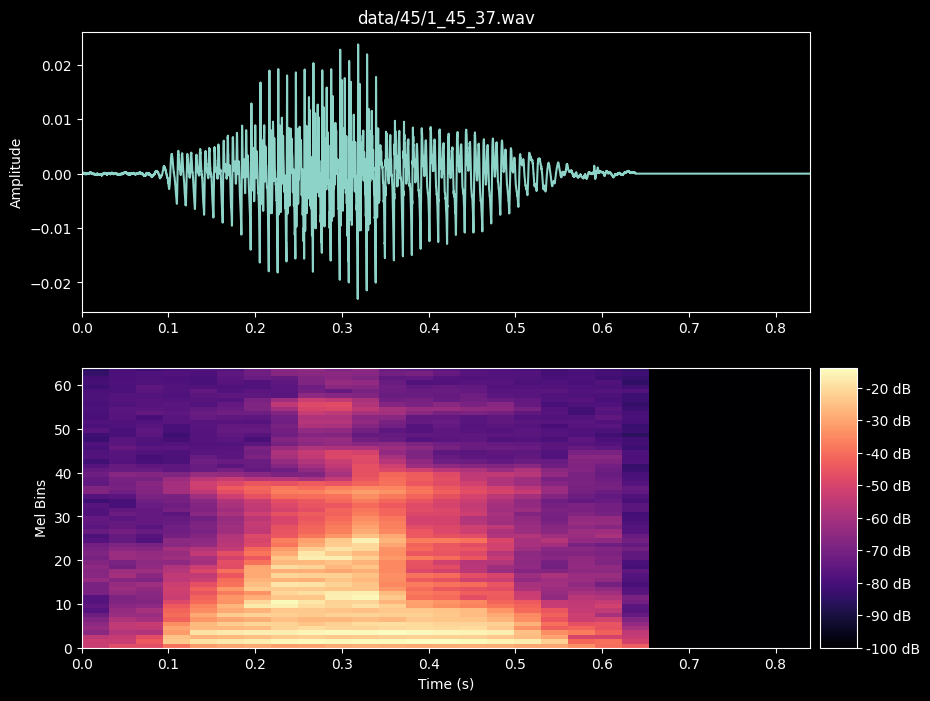

Original: 30642 samples (0.64s)
Preprocessed: 13440 samples (0.84s)


In [4]:
def visualise_audio_data() -> None:
    waveform_transformer = get_waveform_transformer()
    spectrogram_transformer = get_spectrogram_transformer()

    for i in range(3):
        file = get_random_audio(INPUT_DIR)

        raw_waveform, raw_sample_rate = torchaudio.load(file, normalize=True)
        new_waveform = waveform_transformer(raw_waveform)
        mel_spectrogram = spectrogram_transformer(new_waveform)

        new_samples = new_waveform.shape[1]
        new_duration = new_samples / AUDIO_CONFIG.target_sample_rate

        # Plotting
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

        # Waveform
        ax1.plot(np.linspace(0, new_duration, new_samples), new_waveform.t().numpy())
        ax1.set_title(file)
        ax1.set_xlim(0, new_duration)
        ax1.set_ylabel('Amplitude')

        # Placeholder to allow the two graphs to align
        div1 = make_axes_locatable(ax1)
        cax1 = div1.append_axes("right", size="5%", pad=0.1)
        cax1.axis("off")

        # Mel Spectrogram
        img = ax2.imshow(
            mel_spectrogram[0].numpy(),
            origin='lower',
            aspect='auto',
            cmap='magma',
            extent=[0, new_duration, 0, AUDIO_CONFIG.n_mels],
        )
        ax2.set_ylabel('Mel Bins')
        ax2.set_xlabel('Time (s)')

        div2 = make_axes_locatable(ax2)
        cax2 = div2.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(img, cax=cax2, format='%+2.0f dB')

        plt.show()

        display(Audio(data=new_waveform, rate=AUDIO_CONFIG.target_sample_rate))
        print(f'Original: {raw_waveform.shape[1]} samples ({raw_waveform.shape[1]/raw_sample_rate:.2f}s)')
        print(f'Preprocessed: {new_samples} samples ({new_duration:.2f}s)')

visualise_audio_data()

### Determining the 95th percentile for audio lengths

In [5]:
# Need this to be able to determine the best time to truncate / pad to
def calculate_audio_lengths() -> None:
    audio_files = glob.glob(os.path.join(INPUT_DIR, '**/*.wav'), recursive=True)

    durations = []
    for file in tqdm(audio_files):
        info = torchaudio.info(file)
        duration = info.num_frames / info.sample_rate
        durations.append(duration)

    durations = np.array(durations)

    plt.hist(durations, bins=60)
    plt.title('Distribution of audio durations')
    plt.xlabel('Seconds')
    plt.ylabel('No. of files')
    plt.show()

    print(f'95% percentile: {np.percentile(durations, 95):.2f}s')

### Training script

In [6]:
if __name__ == '__main__':
    dataset = AudioDataset(data_dir=INPUT_DIR, pipeline=get_cnn_pipeline())
    train_dataloader, val_dataloader, test_dataloader = get_split_dataloaders(dataset)

    # Get one batch from the training loader and make sure it looks good
    features, labels = next(iter(train_dataloader))
    print(f'Features shape: {features.shape}')
    print(f'Labels shape: {labels.shape}')
    print()

    # Train the model
    model = CNNAudioClassifier().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    # Keep track of best model
    print('Training CNN...')
    best_accuracy = 0.0
    for epoch in range(NUM_EPOCHS):
        saved = False

        print(f'[Epoch {epoch + 1}/{NUM_EPOCHS}]')
        train_loss, train_accuracy = train_one_epoch_cnn(device, model, criterion, optimizer, train_dataloader)
        val_loss, val_accuracy = validate_cnn(device, model, criterion, val_dataloader)

        if val_accuracy > best_accuracy:
            saved = True
            best_accuracy = val_accuracy
            torch.save(model.state_dict(), MODEL_PATH)

        print(f'Train Loss: {train_loss:.2f} | Train Accuracy: {train_accuracy:.2f}% | Val Loss: {val_loss:.2f} | Val Accuracy: {val_accuracy:.2f}%')
        print()
    print(f'Best model had an accuracy of {best_accuracy:.2f}%.')
    print(f'Running final test:')

    checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint, strict=True)
    model.to(device)

    test_accuracy, macs = benchmark_cnn(device, model, test_dataloader)
    print(f'Test accuracy: {test_accuracy:.2f}% | Total MACs: {macs}')

Features shape: torch.Size([64, 1, 64, 27])
Labels shape: torch.Size([64])

Running final test:


Benchmarking: 100%|██████████| 47/47 [00:01<00:00, 37.49batches/s]

Test accuracy: 95.83% | Total MACs: 372922
